  0%|                                                                    | 0/1 [00:00<?, ?it/s]

OrderedDict({'t0': 2462774.5545595586, 'u0': 1.0507575756702343, 'tE': np.float64(3.216435539023663), 'rho': 0.06384795192509116, 'fsource_g': np.float64(582907.9788672349), 'ftotal_g': np.float64(582907.9788672349), 'fblend_g': np.float64(0.0), 'gblend_g': np.float64(0.0)})
12.616
chequeo 12.616


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7e8238a1d460>>
Traceback (most recent call last):
  File "/home/anibal-pc/anaconda3/envs/rubin-sim/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


mag_base 12.616
mag_base pyLIMA 12.616


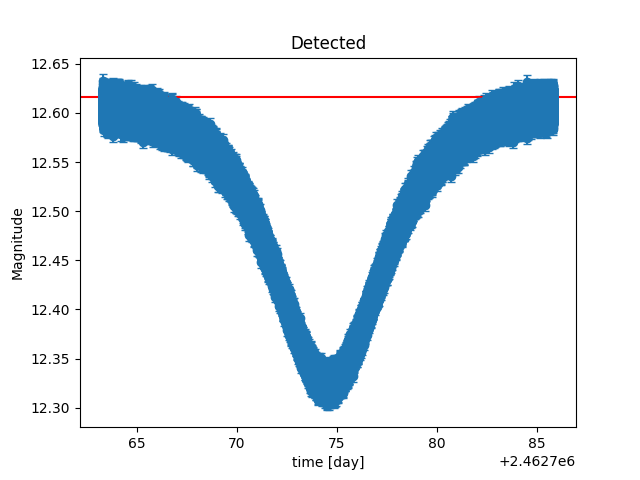

100%|████████████████████████████████████████████████████████████| 1/1 [00:19<00:00, 19.43s/it]


In [5]:
import h5py
import pandas as pd
import numpy as np
import os,sys
import matplotlib.pyplot as plt
from astropy import units as u
path_home = "/home/anibal-pc"
sys.path.append(path_home+'/microlensing/simulation_Rubin/roman_rubin/')
from class_analysis import Analysis_Event
from Sim_Fit_Event import simulation_event, mag
from ulens_params import microlensing_params
current_path = path_home+'/microlensing/simulation_Rubin/roman_rubin/'
path_ephemerides= current_path+'/ephemerides/Roman_positions.npy'
path_dataslice = current_path+'/opsims/baseline/dataSlice.npy'
# script_dir = path_home+'/microlensing/simulation_Rubin/roman_rubin/'

from astropy.table import QTable
from scipy.interpolate import interp1d

def add_noise(pyLIMA_telescope, event):
    """
    Add magnitude noise to CS or ODI light curve.
    """

    m = np.array([9,10,11,12,13,14,15,16,17,18,19,20,21,22,23])

    S_N = {
        "ODI": np.array([5228.1,3298.5,2080.8,1312.3,827.1,520.4,326.1,202.2,122.5,70.7,37.5,18,7.9,3.3,1.3]),
        "CS":  np.array([908.5,573,361.2,227.4,142.6,88.7,54.1,31.6,17.1,8.4,3.7,1.6,0.6,0.3,0.1])
    }

    
    # S_N_CS=np.array([908.5,573,361.2,227.4,142.6,88.7,54.1,31.6,17.1,8.4,3.7,1.6,0.6,0.3,0.1])
    # S_N_ODI=np.array([5228.1,3298.5,2080.8,1312.3,827.1,520.4,326.1,202.2,122.5,70.7,37.5,18,7.9,3.3,1.3])

    telescope_name = event.name
    ZP = event.ZP_dict
    #ZP = {'W149': 27.615, 'CS': 27.03, 'ODI': 27.615}

    if telescope_name not in S_N:
        raise ValueError("telescope_name debe ser 'ODI' o 'CS'")

    SN_interp_log = interp1d(
        m,
        np.log10(S_N[telescope_name]),
        kind="linear",
        bounds_error=True
    )

    def delta_m(Signal_to_noise):
        return (2.5 / np.log(10)) / Signal_to_noise

    # def SN(mag_value):
        # return 10**SN_interp_log(mag_value)
    def SN(mag_value):
        mag_value = np.asarray(mag_value)
    
        mag_min = SN_interp_log.x[0]
        mag_max = SN_interp_log.x[-1]
    
        mag_clipped = np.clip(mag_value, mag_min, mag_max)
    
        return 10**SN_interp_log(mag_clipped)
    def sigma_m(mag_value):
        return delta_m(SN(mag_value))

    X = pyLIMA_telescope.lightcurve["time"].value
    flux = pyLIMA_telescope.lightcurve["flux"].value

    ym = mag(ZP[telescope_name], flux)

    err_mag = sigma_m(ym)

    mag_noisy = np.random.normal(
        loc=ym,
        scale=err_mag
    )

    data_tbl = QTable(
        [
            pyLIMA_telescope.lightcurve["err_flux"].value,
            err_mag,
            flux,
            pyLIMA_telescope.lightcurve["inv_err_flux"].value,
            mag_noisy,
            X,
        ],
        names=(
            "err_flux",
            "err_mag",
            "flux",
            "inv_err_flux",
            "mag",
            "time",
        ),
    )
    pyLIMA_telescope.lightcurve = data_tbl

    return pyLIMA_telescope


def odi_run(i,path_TRILEGAL_set, path_GENULENS_set, savepath,  path_ephemerides, path_dataslice, rho, telescope_name):
    ra, dec= 267.92497054815516, -29.152232510353276
    system_type = 'lenses_low_mass'
    model = 'FSPL'
    orbital_period = 0
    ZP = {'W149': 27.615, 'CS': 27.03, 'ODI': 27.615}
    mag_lim_dict = {'W149': 27.6, 'CS': 18.65, 'ODI': 21.54}
    ROW = i-10000*int(i/10000)
    seed = i
    mag_lim=18.7
    data_trilegal = pd.read_csv(path_TRILEGAL_set)
    data_trilegal = data_trilegal[data_trilegal["g"]<mag_lim]
    TRILEGAL_row = data_trilegal.iloc[ROW+1]
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    # print(len(data_trilegal))
    GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1, header=None)
    GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns
    
    event = simulation_event(ra, dec, 69, path_ephemerides, path_dataslice,
                        TRILEGAL_row, GENULENS_row.iloc[0], system_type, model, 0, telescope_name, ZP)
    params = event.event_param()
    # print("Event name", event.name)
    if params['rho']>99:
        print("rho>99 source too large")
        return 0,0,0,0
    delta_t = 3.5*params['tE']#*np.sqrt((1 + params['rho'])**2 - params['u0']**2)
    # print(params['tE'],params['rho'],params['u0'], delta_t)
    tini,tfin = params['t0']-delta_t, params['t0']+delta_t
    
    timestamps = np.arange(tini,tfin,2/86400)
    if not event.name =="W149":
        event_pyLIMA = event.Event_Rubin_custom_cadence({'g':timestamps})
    else:
        event_pyLIMA = event.Event_roman_ODI()
    my_own_model2, pyLIMA_parameters = event.sim_clear_Rubin_lightcurves(event_pyLIMA, params)
    # print("Add noise")
    if not event.name =="W149":
        my_own_model2.event.telescopes[0] = add_noise(my_own_model2.event.telescopes[0], event)

    A_max = max(my_own_model2.model_magnification(my_own_model2.event.telescopes[0],pyLIMA_parameters))
    sigma_magmax = my_own_model2.event.telescopes[0].lightcurve["mag_err"]
    
    decision = event.deviation_from_constant(pyLIMA_parameters, my_own_model2.event.telescopes)
    # print("telescopes ", my_own_model2.event.telescopes[0].name)
    return my_own_model2, pyLIMA_parameters, TRILEGAL_row[my_own_model2.event.telescopes[0].name], decision
from tqdm import tqdm
ZP = {'W149': 27.615, 'CS': 27.03, 'ODI': 27.615}
# 585
%matplotlib widget

for j in tqdm(range(1)):
    i=1
    # j=22
    path_TRILEGAL_set = current_path+f'/chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_{i}.csv'
    path_GENULENS_set = current_path+f'/chunks_TRILEGAL_GENULENS/Genulens_chunk_{i}.csv'
    tel = "CS"
    my_own_model2, pyLIMA_parameters ,mag_base, decision = odi_run(j,path_TRILEGAL_set, path_GENULENS_set, False ,  "", "",0.4,tel)
    print(pyLIMA_parameters)
    print(mag_base)
    print("chequeo",ZP["CS"] - 2.5 * np.log10(pyLIMA_parameters['ftotal_' + f'{"g"}']))
    # print(decision)
    # if not int(decision):
    #     print(j)
    if not my_own_model2==0:
        # print(pyLIMA_parameters)
        tel_lc = my_own_model2.event.telescopes[0].lightcurve
        # print(my_own_model2.event.telescopes[0].name)
        # %matplotlib inline
        plt.close("all")
        plt.errorbar(tel_lc["time"], tel_lc["mag"],tel_lc["err_mag"], ls="",marker="o",capsize=3)
        print("mag_base",mag_base)
        print("mag_base pyLIMA",mag(ZP[tel],pyLIMA_parameters["ftotal_g"]))
        if decision:
            plt.title(f"Detected")
        else:
            plt.title(f"Not detected")
        plt.axhline(mag_base,color="red")
        
        # plt.axvline(pyLIMA_parameters["t0"])
        plt.xlabel("time [day]")
        plt.ylabel("Magnitude")
        plt.show()

In [3]:
from astropy import units as u
10**-6*u.M_sun.to("M_earth")

0.33294607832806994

In [3]:
np.log10(0.01*u.M_earth.to("M_jup"))

np.float64(-4.502192710605739)

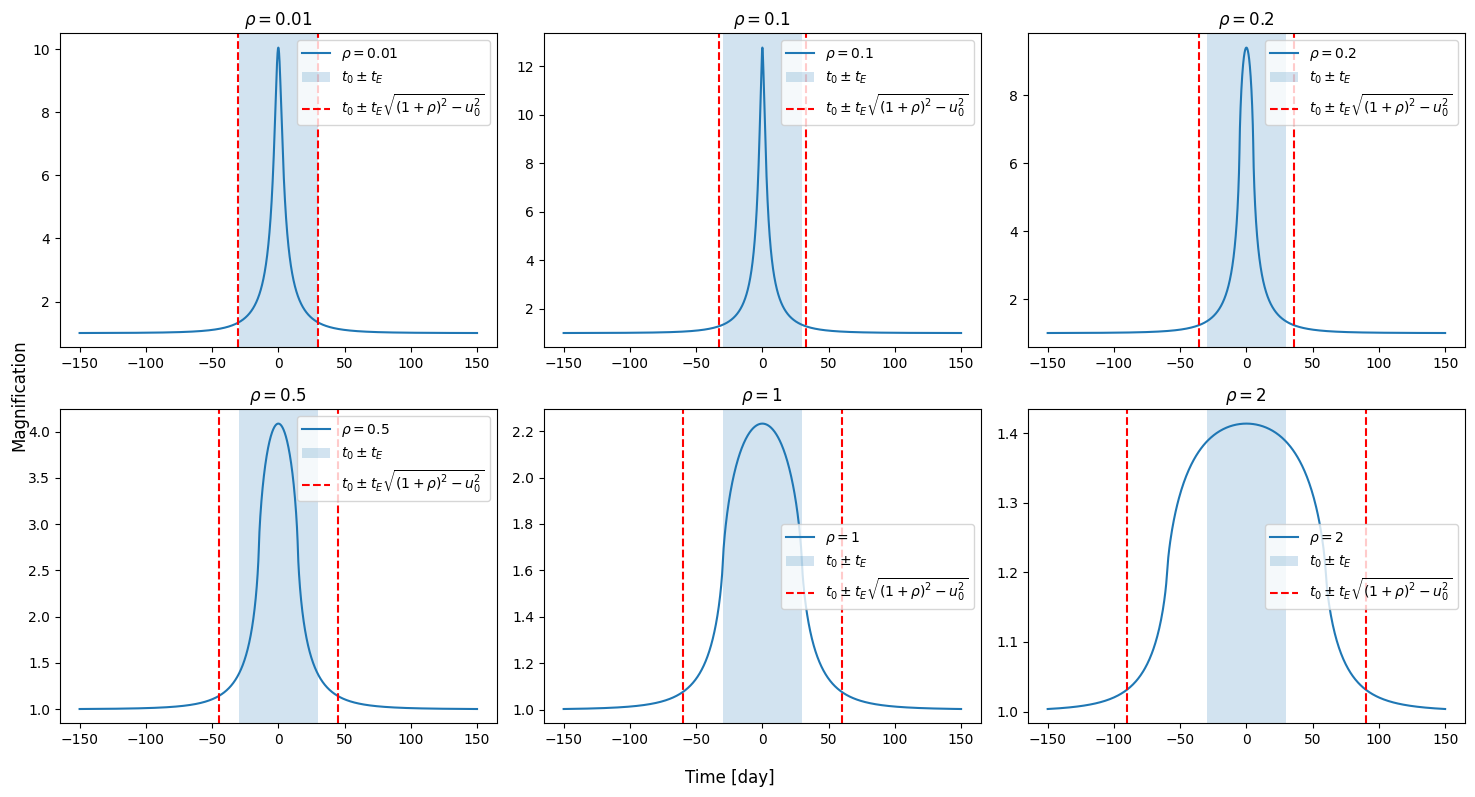

In [3]:
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.models import FSPLarge_model
import numpy as np
import matplotlib.pyplot as plt
simulated_event = event.Event()

simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-150, 150, 5000)
lightcurve_sim = np.c_[t, np.full_like(t, 19.0), np.full_like(t, 0.000000001)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)


# case_name, df_row =  "case2", df_cases.loc["case2"]
# params_list = [0]*12
model = FSPLarge_model.FSPLargemodel(simulated_event, parallax=['None', 0]) 
model.define_model_parameters()


rhos = [0.01, 0.1, 0.2, 0.5, 1, 2]
plt.close("all")
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()  # para iterar fácil
t0=0
u0=0.1
tE=30 

for i, rho in enumerate(rhos):
    
    ax = axes[i]
    
    # my_own_model2, pyLIMA_parameters = odi_run(
        # i, path_TRILEGAL_set, path_GENULENS_set,
        # savepath, path_ephemerides, path_dataslice, rho
    # )1
    #rho=0.1
    params_list = [t0,u0,tE,rho]
    pyLIMA_parameters = model.compute_pyLIMA_parameters(params_list)
    
    tel = model.event.telescopes[0]#.lightcurve
    
    # pyLIMA_parameters["tE"] = 30
    
    A = model.model_magnification(
        tel,
        pyLIMA_parameters
    )#["photometry"]
    
    t = tel.lightcurve["time"]
    
    u0 = pyLIMA_parameters["u0"]
    t0 = pyLIMA_parameters["t0"]
    tE = pyLIMA_parameters["tE"]
    r  = pyLIMA_parameters["rho"]
    
    # curva
    ax.plot(t, A, label=f"$\\rho={r}$")
    
    # zoom temporal
    # ax.set_xlim(t0 - 5*tE, t0 + 5*tE)
    
    # región t0 ± tE
    ax.axvspan(t0 - tE, t0 + tE, alpha=0.2, label="$t_0\pm t_E$")
    
    # bordes fuente finita
    delta_t = tE * np.sqrt((1 + r)**2 - u0**2)
    ax.axvline(t0 - delta_t, linestyle="--",color="red", label=r"$t_0\pm t_E\sqrt{(1+\rho)^2-u_0^2}$")
    ax.axvline(t0 + delta_t, linestyle="--",color="red")
    
    ax.set_title(f"$\\rho = {r}$")
    ax.legend()

# etiquetas globales
fig.supxlabel("Time [day]")
fig.supylabel("Magnification")

plt.tight_layout()
plt.savefig("/home/anibal-pc/fig_martin_criterio.png")
plt.show()


  0%|          | 0/30 [00:00<?, ?it/s]

ES 1? 1.0003169339632927
5.00483641061207e-05


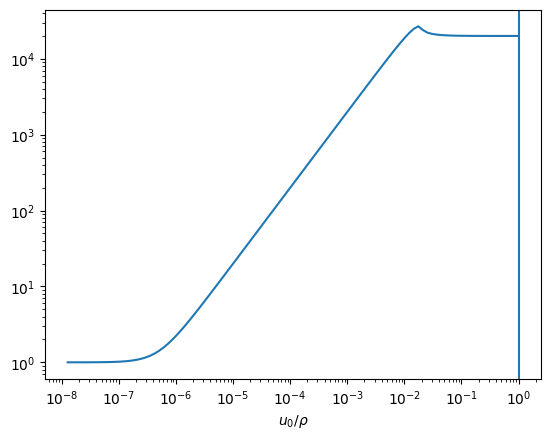

ES 1? 1.0003169339632931
5.0068744611544883e-05


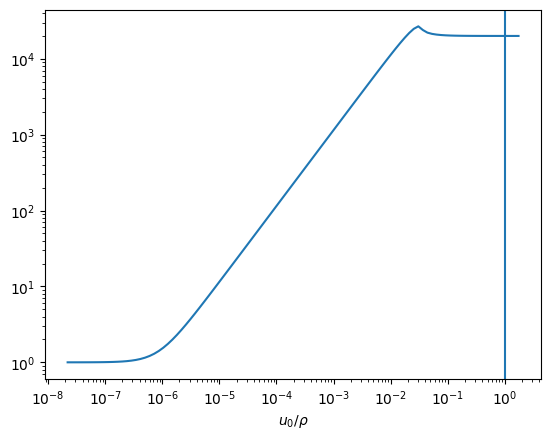

ES 1? 1.0003169339632931
5.013063409641514e-05


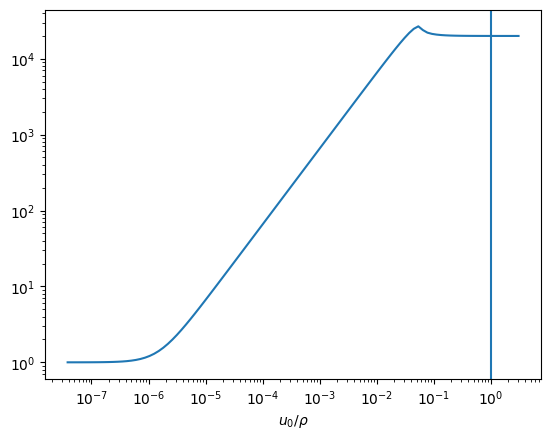

ES 1? 1.0003169339632931
5.031826113910537e-05


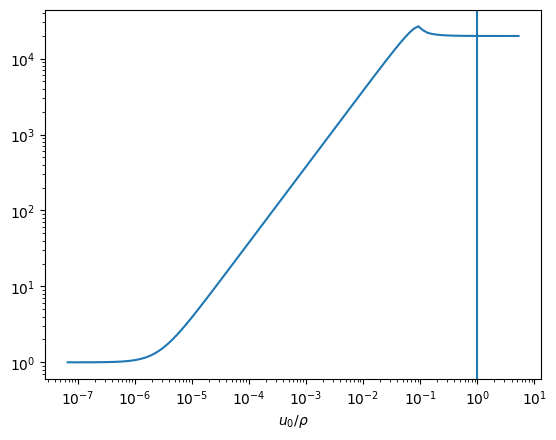

ES 1? 1.0003169339632931
5.088425037258347e-05


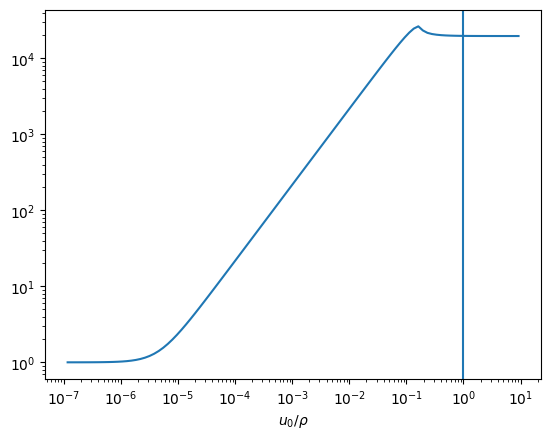

ES 1? 1.0003169339632931
5.256701347253083e-05


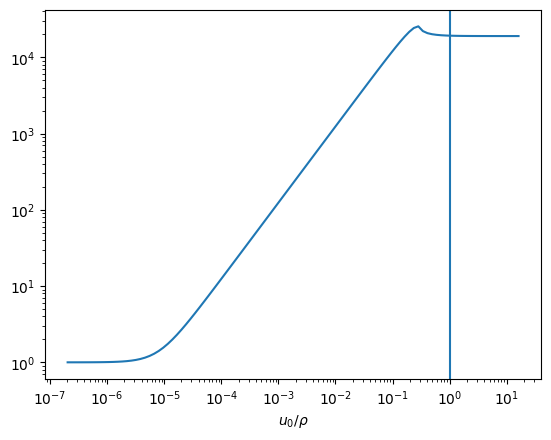

ES 1? 1.0003169339632927
5.737916318812448e-05


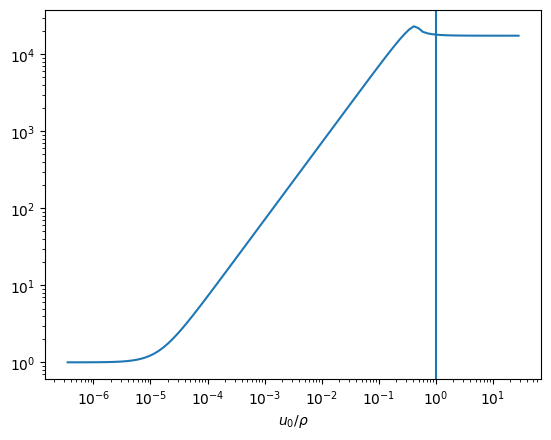

ES 1? 1.0003169339632927
7.000252258519393e-05


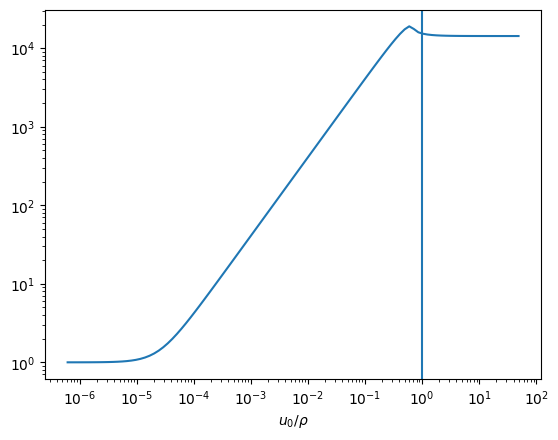

ES 1? 1.0003169339632922
9.893130915344403e-05


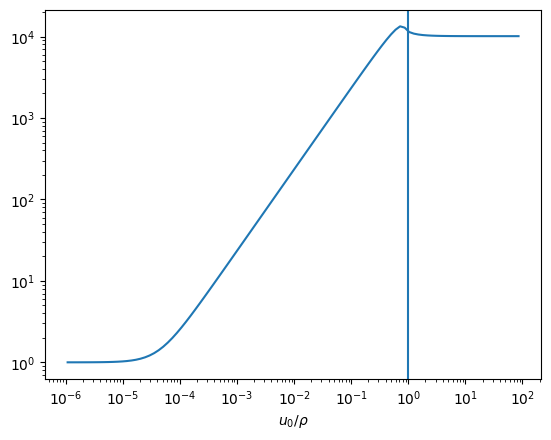

ES 1? 1.0003169339632918
0.00015697096237079756


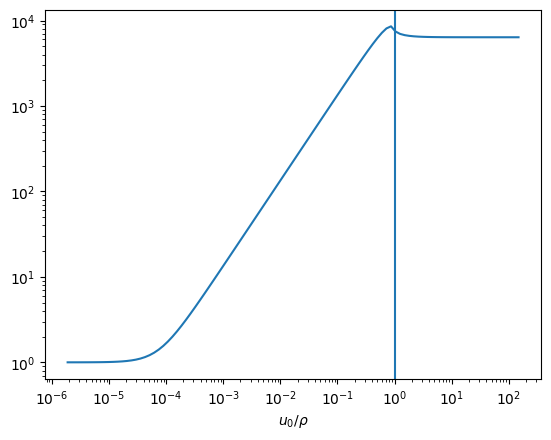

ES 1? 1.0003169339632905
0.000264158330237891


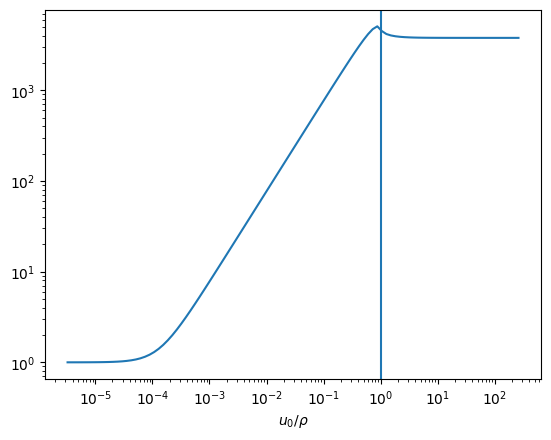

ES 1? 1.0003169339632878
0.0004549378340668307


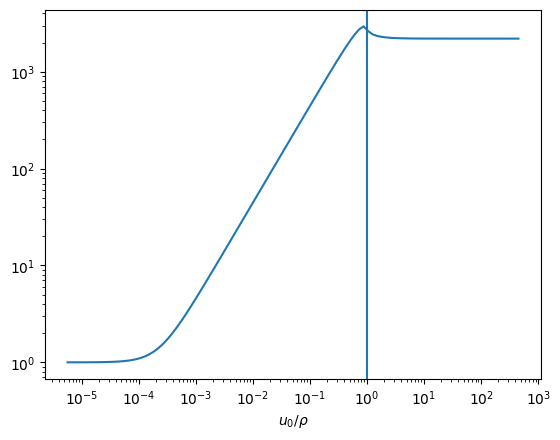

ES 1? 1.0003169339632834
0.0007898813000807306


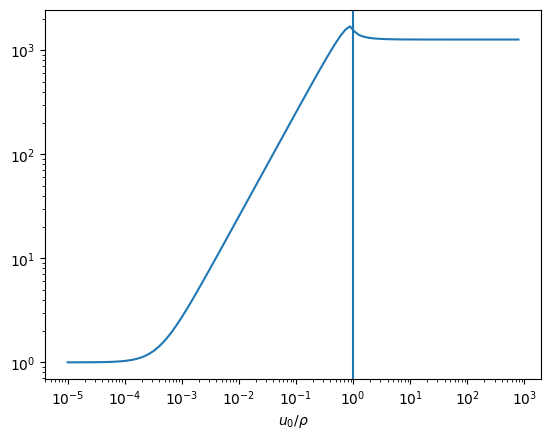

ES 1? 1.0003169339632758
0.0013751677489148185


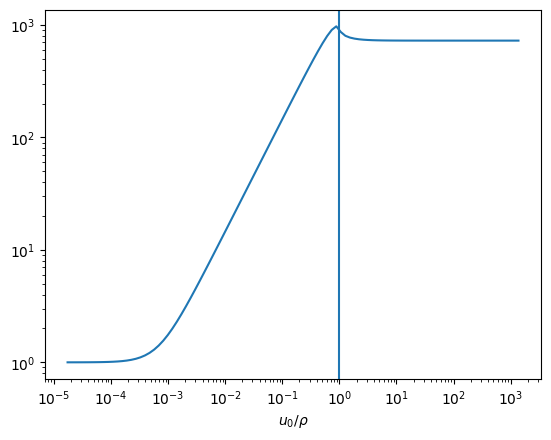

ES 1? 1.000316933963263
0.002396301823767578


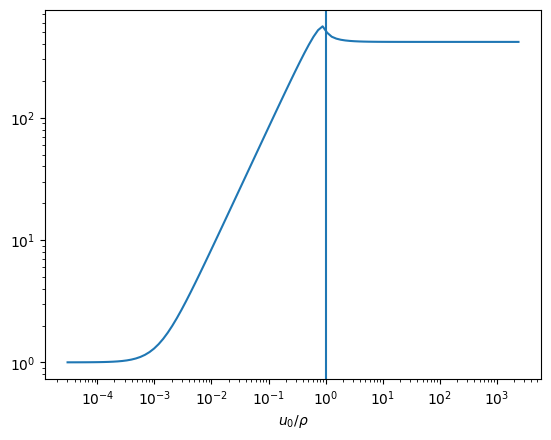

ES 1? 1.0003169339632398
0.004176913438282742


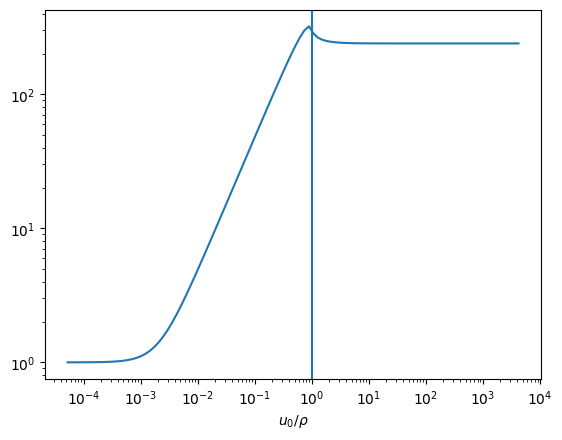

ES 1? 1.0003169339631999
0.0072812868178647175


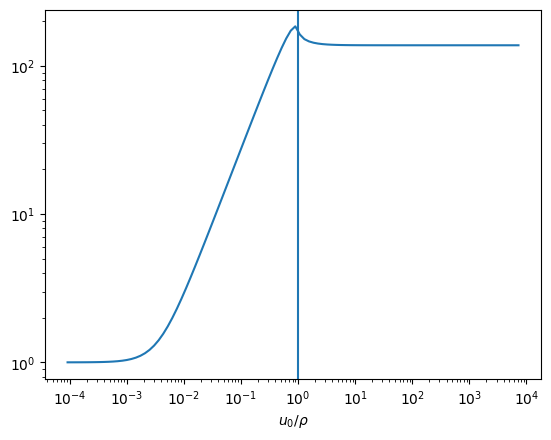

ES 1? 1.0003169339631306
0.012692962723472142


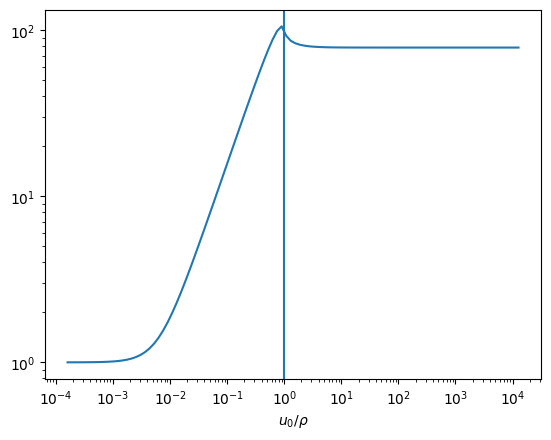

ES 1? 1.0003169339630094
0.02212516925058626


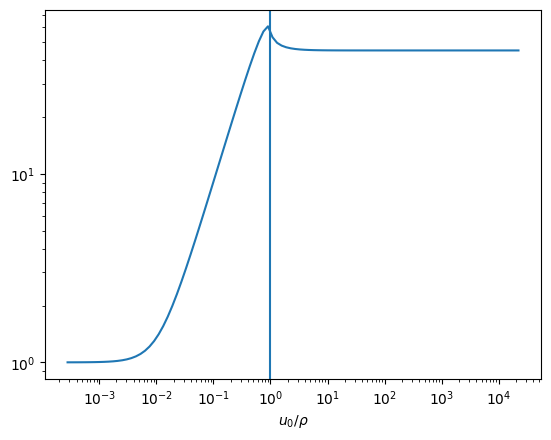

ES 1? 1.000316933962798
0.0385569562366891


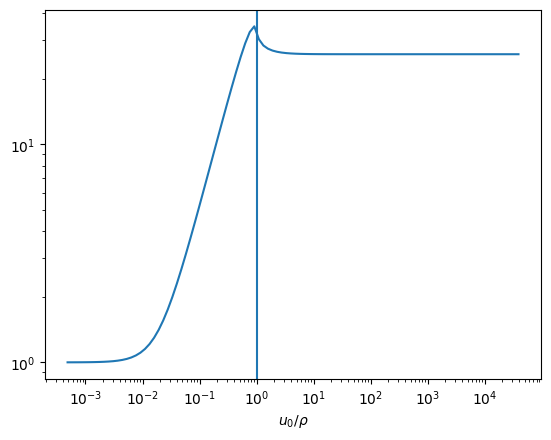

ES 1? 1.0003169339624294
0.06714114168083338


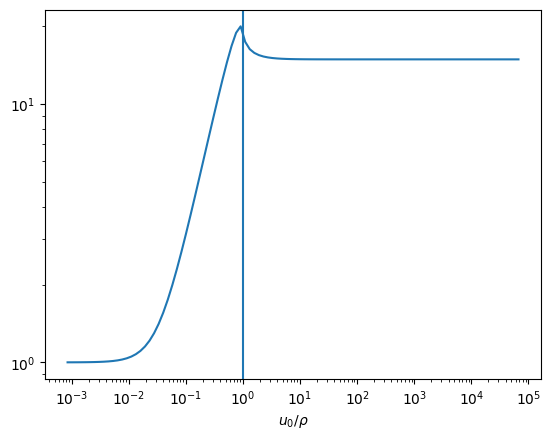

ES 1? 1.000316933961787
0.11664729678947126


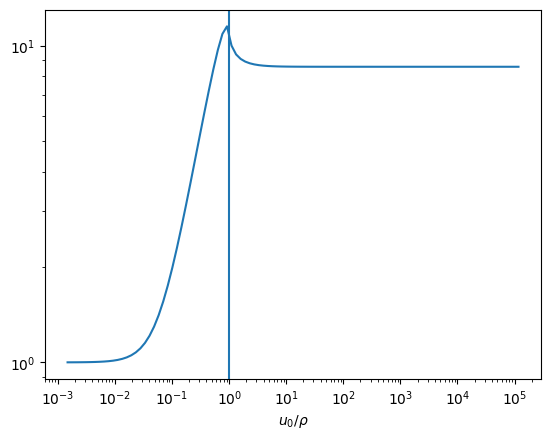

ES 1? 1.0003169339606672
0.2012630781594336


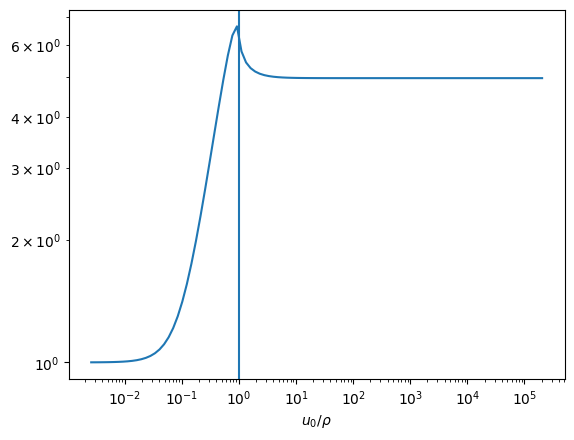

ES 1? 1.0003169339587146
0.3403511746045752


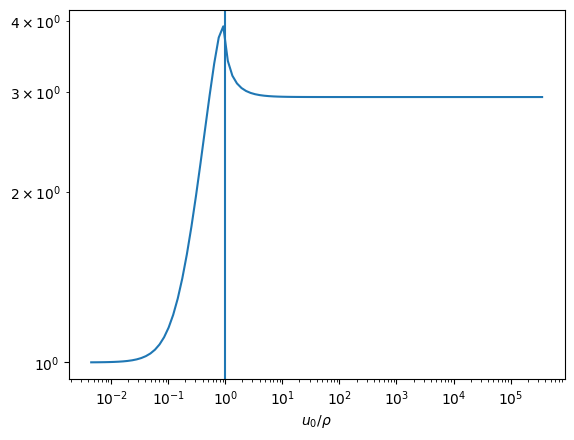

ES 1? 1.0003169339553108
0.5453178700343904


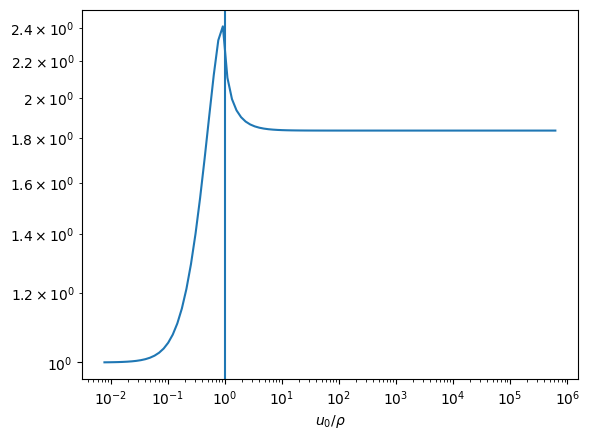

ES 1? 1.0003169339419573
0.7764379383436985


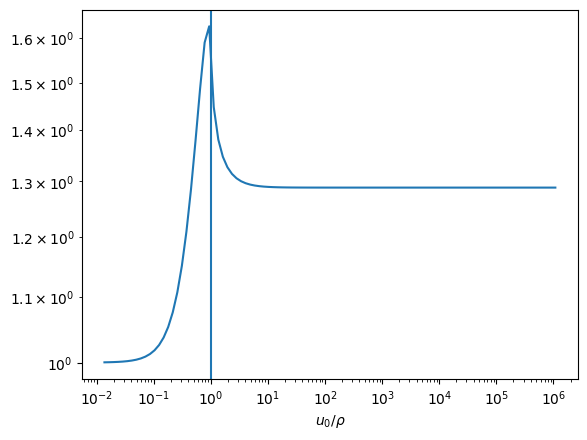

ES 1? 1.000316933903194
0.9334150613757577


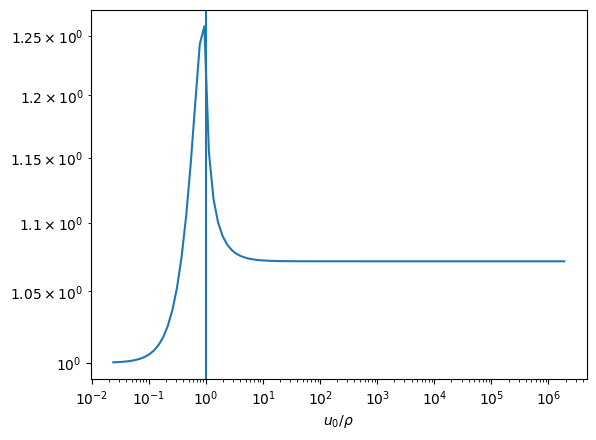

ES 1? 1.0003169337863889
0.9880813549977888


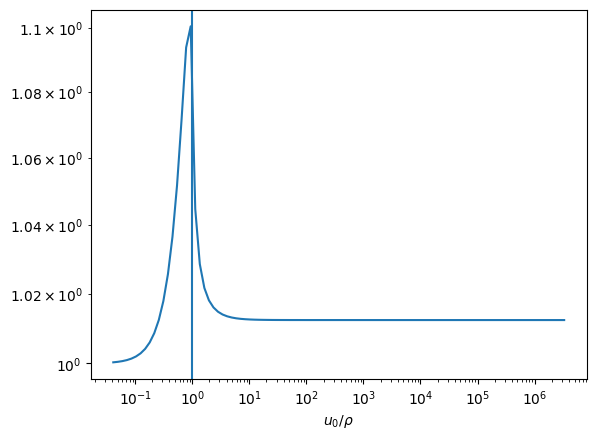

ES 1? 1.0003169334248323
0.9986733642039367


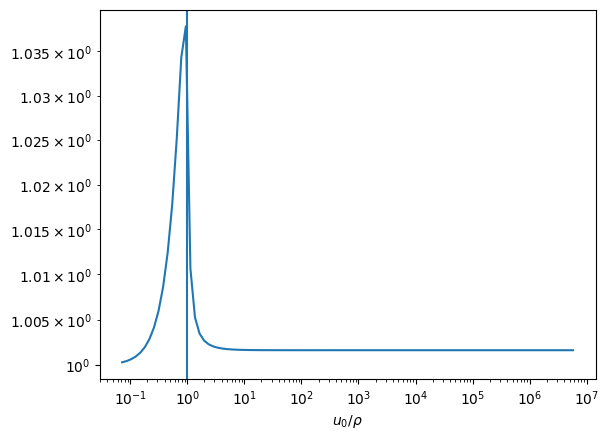

ES 1? 1.0003169323030527
1.0001246190103898


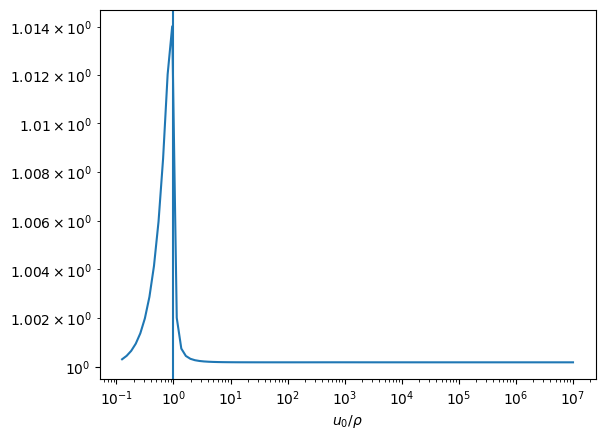

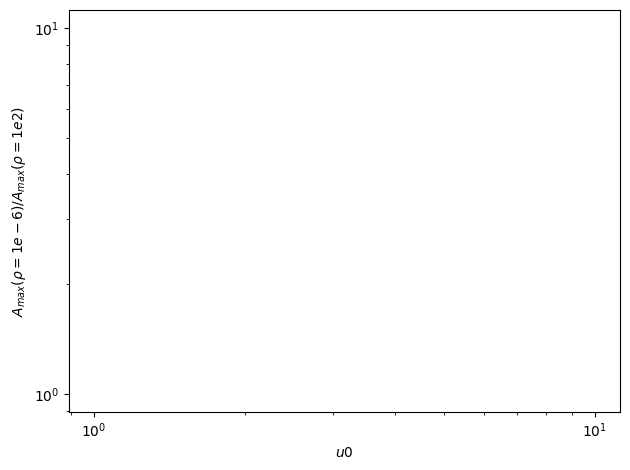

In [104]:
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.models import FSPLarge_model
import numpy as np
import matplotlib.pyplot as plt
simulated_event = event.Event()
t0=0
tE=5

simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70
t = np.linspace(-tE, tE, 2000)
lightcurve_sim = np.c_[t, np.full_like(t, 19.0), np.full_like(t, 0.000000001)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)


# case_name, df_row =  "case2", df_cases.loc["case2"]
# params_list = [0]*12
model = FSPLarge_model.FSPLargemodel(simulated_event, parallax=['None', 0]) 
model.define_model_parameters()


rhos = np.logspace(-6,1.9,100)
plt.close("all")
# fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
# axes = axes.flatten()  # para iterar fácil

u0s = np.logspace(-6,1,30)

from tqdm.auto import tqdm
tEs = np.linspace(5,365,30)

for tE in tqdm(tEs):
    tE = 50
    ratio_Amax = []
    for u0 in u0s:
        #u0=10**(1.99)#u0s[-1]
        A_max = []
        for i, rho in enumerate(rhos):
            params_list = [t0,u0,tE,rho]
            pyLIMA_parameters = model.compute_pyLIMA_parameters(params_list)    
            tel = model.event.telescopes[0]
            
            A = model.model_magnification(
                tel,
                pyLIMA_parameters)
            A_max.append(max(A))
        print("ES 1?", A_max[-1])
        ratio_Amax.append(A_max[-1]/A_max[0])
        print(A_max[-1]/A_max[0])
        # plt.title(f"u0={u0}, tE={tE}")
        plt.axvline(1)
        plt.plot(u0/rhos, A_max)
        plt.xlabel(r"$u_0/\rho$")
        plt.xscale("log")
        plt.yscale("log")
        plt.show()
    break
    # plt.plot(u0s,ratio_Amax,label=f"tE={tE} day")

# etiquetas globales
fig.supxlabel("Time [day]")
plt.xlabel(r"$u0$")
plt.ylabel(r"$A_{max}(\rho=1e-6)/A_{max}(\rho=1e2)$")
fig.supylabel("Magnification")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()


  0%|          | 0/30 [00:00<?, ?it/s]

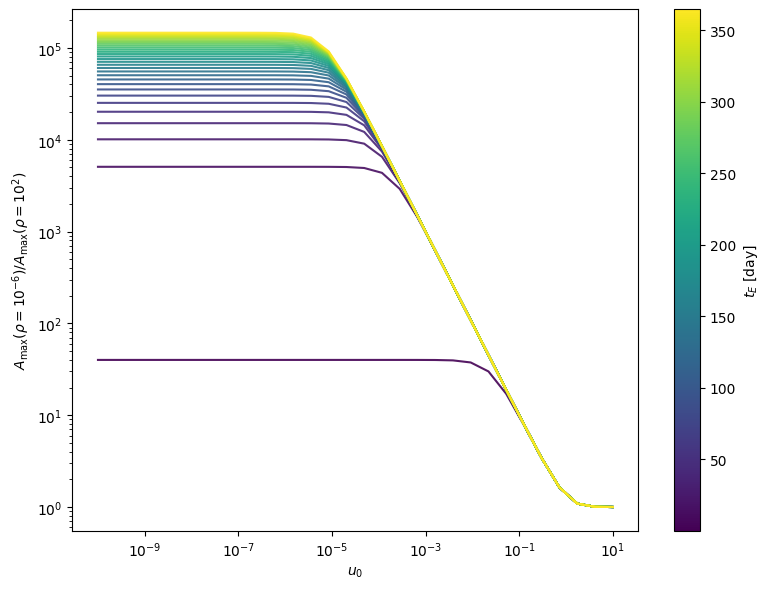

In [85]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

rhos = np.logspace(-6, 2, 100)   # llega hasta 1e2
u0s = np.logspace(-10, 1, 30)
tEs = np.linspace(0.1, 365, 30)

plt.close("all")

fig, ax = plt.subplots(figsize=(8, 6))

# Colormap para asignar un color a cada tE
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=tEs.min(), vmax=tEs.max())
ratio_Amax_low = []
for tE in tqdm(tEs):
    
    simulated_event.name = 'Simulated'
    simulated_event.ra = 170
    simulated_event.dec = -70
    t = np.linspace(-tE, tE, 2000)
    lightcurve_sim = np.c_[t, np.full_like(t, 19.0), np.full_like(t, 0.000000001)]
    
    tel = telescopes.Telescope(
        name='Simulation',
        camera_filter='G',
        lightcurve=lightcurve_sim.astype(float),
        lightcurve_names=['time','mag','err_mag'],
        lightcurve_units=['JD','mag','mag'],
        location='Earth'
    )
    simulated_event.telescopes.append(tel)
    
    
    # case_name, df_row =  "case2", df_cases.loc["case2"]
    # params_list = [0]*12
    model = FSPLarge_model.FSPLargemodel(simulated_event, parallax=['None', 0]) 
    model.define_model_parameters()
    
    


    ratio_Amax = []

    for u0 in u0s:

        A_max = []

        for rho in rhos:
            params_list = [t0, u0, tE, rho]
            pyLIMA_parameters = model.compute_pyLIMA_parameters(params_list)

            tel = model.event.telescopes[0]

            A = model.model_magnification(
                tel,
                pyLIMA_parameters
            )

            A_max.append(np.max(A))

        # Como el ylabel dice:
        # Amax(rho=1e-6) / Amax(rho=1e2)
        ratio_Amax.append(A_max[0] / A_max[-1])
    
    color = cmap(norm(tE))
    ratio_Amax_low.append(ratio_Amax[0])
    ax.plot(
        u0s,
        ratio_Amax,
        color=color,
        alpha=0.9
    )

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$t_E$ [day]")

ax.set_xlabel(r"$u_0$")
ax.set_ylabel(r"$A_{\max}(\rho=10^{-6})/A_{\max}(\rho=10^{2})$")

ax.set_xscale("log")
ax.set_yscale("log")

fig.tight_layout()
plt.show()

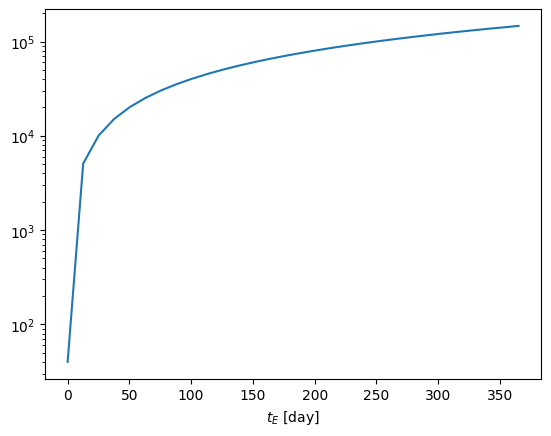

In [89]:
plt.plot(tEs,ratio_Amax_low)
plt.xlabel(r"$t_E$ [day]")
plt.xlabel(r"ratio $A_{max}(u_0)$")
plt.yscale("log")

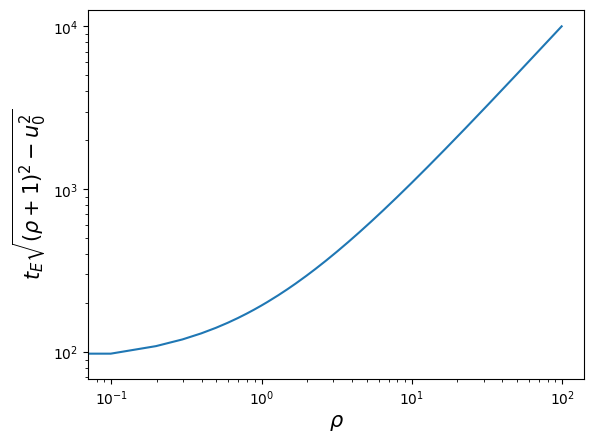

In [4]:
tE = 100
u0=0.5
r = np.linspace(0,99,1000)
delta_t = tE * np.sqrt((1 + r)**2 - u0**2)
plt.close("all")
plt.plot(r,delta_t)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\rho$",fontsize=15)
plt.ylabel(r"$t_E\sqrt{(\rho+1)^2-u_0^2}$",fontsize=15)
plt.show()

In [5]:
path_TRILEGAL_set = f'/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_{i}.csv'
trilegal_df = pd.read_csv(path_TRILEGAL_set)

def estimate_n_sources(trilegal_df, mag_col, lim_mag, fov_deg2, omega_trilegal_deg2=1.0):
    """
    Estima el número de fuentes observables para un instrumento.

    trilegal_df: catálogo TRILEGAL
    mag_col: banda usada, por ejemplo 'g' o 'W149'
    lim_mag: magnitud límite
    fov_deg2: FOV del instrumento en deg^2
    omega_trilegal_deg2: área representada por el catálogo TRILEGAL
    """
    visible = trilegal_df[trilegal_df[mag_col] < lim_mag]
    surface_density = len(visible) / omega_trilegal_deg2
    n_sources = surface_density * fov_deg2

    return n_sources, surface_density

N_ODI, sigma_ODI = estimate_n_sources(trilegal_df, "g", 21.54, 1.0)
N_CS, sigma_CS = estimate_n_sources(trilegal_df, "g", 18.65, 2.16)
N_ROMAN, sigma_ROMAN = estimate_n_sources(trilegal_df, "W149", 27.6, 0.28)

print("ODI:", N_ODI, "fuentes")
print("CS:", N_CS, "fuentes")
print("Roman:", N_ROMAN, "fuentes")

NameError: name 'pd' is not defined